# <span style="color:#FF775C">Value and Model Class</span>

In [52]:
#Imports
from math import exp, log, sin, cos
import numpy as np
import matplotlib.pyplot as plt
import random


In [53]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None # Returns none because gradients should start at 0 when computing derivatives
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other): 
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  # Multiplication
  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self,other), '*')

    def _backward():
      other.grad += self.data * out.grad
      self.grad += other.data * out.grad
    out._backward = _backward

    return out
  
  #Euler
  def exp(self):
    x = max(-700, min(700, self.data)) 
    out = Value(exp(x), (self, ), 'exp')
    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out
  
  #Logarithm
  def log(self):
    
    epsilon = 1e-15
    x = max(epsilon, min(1.0 - epsilon, self.data))

    out = Value(log(x), (self,), "log")
    
    def _backward():
      self.grad += (1/self.data) * out.grad
      
    out._backward = _backward
    return out
  
  # Power
  def __pow__(self, other):
    assert isinstance(other, (int, float))
    out = Value(self.data**other, (self, ), "^")

    def _backward():
      self.grad += (other*(self.data**(other-1))) * out.grad
    out._backward = _backward
    return out
  
  # Sin
  def sin(self):
    out = Value(sin(self.data), (self, ), "sin")
  
    def _backward():
      self.grad += (cos(self.data)) * out.grad
    
    out._backward = _backward
    return out
  
  #Tanh
  def tanh(self):
    e2x = (self * 2).exp()
    return (e2x - 1) / (e2x + 1)
  
  #Sigmoid
  def sigmoid(self):
    return 1/(1+(-self).exp())
  
  def __sub__(self, other):
    return self + (-other)
  def __radd__(self, other):
    return self + other
  def __rmul__(self, other):
    return self * other
  def __rsub__(self, other):
    return self - other
  def __neg__(self):
    return self * -1
  def __truediv__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    return self *(other**-1)
  def __rtruediv__(self, other): 
    return Value(other) * (self**-1)

  def backward(self): 
    topo = [] #Creates an empty list
    visited = set() #Prevents nodes from repeating
    def build_topo(v):
      if v not in visited:
        visited.add(v) #Append to the set so that it does not repeat
        for child in v._prev: #Takes the values that amount to output v
          build_topo(child) #Repeat until every child is accounted for
        topo.append(v) #Append the first child before the parent
    build_topo(self) 

    self.grad = 1.0 #Derivative of final output
    for node in reversed(topo): #Reversed because we want to start from the top
      node._backward() #Calls the backward pass which is the function to get the gradient of the out value

In [54]:
class Module:
    def zero_grad(self, params):
        for p in params:
            p.grad = 0.0
    
    def parameters(self):
        return []

class Neuron(Module):
    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        self.nonlin = nonlin
        
    def __call__(self, x):
        act = sum( wi*xi for wi, xi in zip(self.w, x)) + self.b
        return act.tanh() if self.nonlin else act
        #act.tanh() | Activation function, squashes the sum to a number between -1 to 1. However, it never reaches either number
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer(Module):
    def __init__(self,nin,nout, nonlin=True):
        self.neurons = [Neuron(nin, nonlin=nonlin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP(Module):
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [
            Layer(sz[i], sz[i+1], nonlin=(i != len(nouts)-1))
            for i in range(len(nouts))
        ]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

# <span style="color:#FF775C">Makemoons dataset</span>

### *<span style="color:#6FCB9F">Import and create dataset*</span>

In [55]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=50, noise=0.2, random_state=42)
y

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1])

### *<span style="color:#6FCB9F">Apply model*</span>

<u>Model Structure</u> = **2 Inputs** to **two 16 neuron layers** and **1 Output**

<u>Loss function</u> = **Mean Squared Error** loss

<u>Learning Rate</u> = **0.05**

<u>Epochs</u> = **100**


In [56]:
# Initialize MLP: 2 input features (X1, X2), hidden layers [16, 16], 1 output
n = MLP(2, [16, 16, 1])
losses = []

for k in range(100):
    # 1. Forward pass
    ypred = [n(x) for x in X]
    
    #2. Binary Cross Entropy
    ypred = [n(x).sigmoid() for x in X]  # Apply sigmoid at the very end
    loss = -sum(ygt * yout.log() + (1 - ygt) * (1 - yout).log() for ygt, yout in zip(y, ypred)) / len(y)
    
    # Mean Squared Error (MSE) loss | Use with tanh
    #loss = sum((yout - ygt)**2 for ygt, yout in zip(y, ypred)) / len(y)
    
    # 3. Backward pass
    n.zero_grad(n.parameters())
    loss.backward()

    # 4. Gradient update with stable step size
    for p in n.parameters():
        p.data -= 0.08 * p.grad
    
    losses.append(loss.data)
    
    if k % 10 == 0:
        print(f"Epoch {k} | Loss: {loss.data:.4f}")
    

Epoch 0 | Loss: 17.5801
Epoch 10 | Loss: 17.4805
Epoch 20 | Loss: 17.4547
Epoch 30 | Loss: 17.4466
Epoch 40 | Loss: 17.4422
Epoch 50 | Loss: 17.4386
Epoch 60 | Loss: 17.4351
Epoch 70 | Loss: 17.4318
Epoch 80 | Loss: 17.4288
Epoch 90 | Loss: 17.4260


Text(0.5, 1.0, 'Training loss')

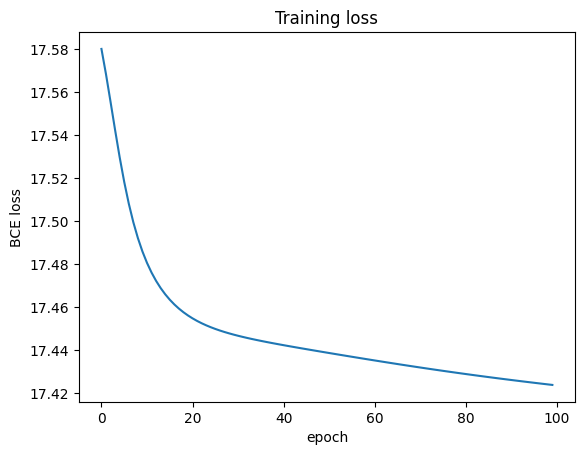

In [57]:
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Training loss")

### *<span style="color:#6FCB9F">Evaluation Metric*</span>

In [58]:
def accuracy(model, inputs, targets, threshold):
    correct = 0
    for x, target in zip(inputs, targets):
        output = model(x)                     # however you call your model
        predicted_label = 1 if output.data > threshold else 0
        correct += (predicted_label == target)
    return f"{(correct / len(targets)) * 100:.0f}%"

accuracy(n, X, y, 0.5)

'80%'

In [59]:
predictions = [1 if n(x).data > 0.5 else 0 for x in X]
print(f"Number of 1 Predicted Outputs: {sum(predictions)} \nTotal Number of Outputs: {len(predictions)}") 

Number of 1 Predicted Outputs: 23 
Total Number of Outputs: 50


In [60]:
print(f"Number of 1 Outputs: {sum(y)} \nTotal Number of y: {len(y)}")   # how many real points are labeled 1, out of 50

Number of 1 Outputs: 25 
Total Number of y: 50


In [61]:
tp = fp = fn = tn = 0
for x, target in zip(X, y):
    pred = 1 if n(x).data > 0.5 else 0
    if pred == 1 and target == 1: tp += 1
    elif pred == 1 and target == 0: fp += 1
    elif pred == 0 and target == 1: fn += 1
    else: tn += 1
print(f"TP={tp} | FP={fp} \nFN={fn} | TN={tn}")

TP=19 | FP=4 
FN=6 | TN=21


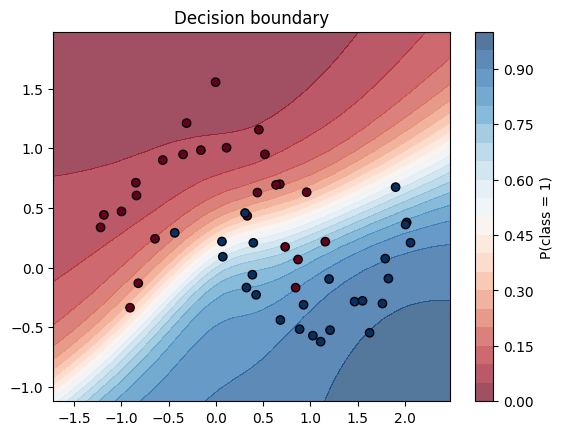

In [63]:
h = 0.1  # grid resolution — see note below
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = []
for x1, x2 in zip(xx.ravel(), yy.ravel()):
    prob = n([Value(x1), Value(x2)]).sigmoid().data
    Z.append(prob)
Z = np.array(Z).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
plt.colorbar(label='P(class = 1)')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k')
plt.title("Decision boundary")
plt.show()

# <span style="color:#FF775C"> Error Logs </span>


another iteration, not needed.

In [48]:
"""n = MLP(50,[50,25,10,1])

for k in range(20):
    # forward pass
    ypred = [n(x) for x in X]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(y, ypred))

    # backward pass
    n.zero_grad(n.parameters())
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.002 * p.grad

    print(k, loss.data)"""

'n = MLP(50,[50,25,10,1])\n\nfor k in range(20):\n    # forward pass\n    ypred = [n(x) for x in X]\n    loss = sum((yout - ygt)**2 for ygt, yout in zip(y, ypred))\n\n    # backward pass\n    n.zero_grad(n.parameters())\n    loss.backward()\n\n    # update\n    for p in n.parameters():\n        p.data += -0.002 * p.grad\n\n    print(k, loss.data)'

-0.3 as the threshold even though the values can only be between 0 to 1

In [49]:
"""predictions = [1 if n(x).data > -0.3 else 0 for x in X]
print(sum(predictions), len(predictions))   # if this is close to 50/0 or 0/50, that's your answer"""

"predictions = [1 if n(x).data > -0.3 else 0 for x in X]\nprint(sum(predictions), len(predictions))   # if this is close to 50/0 or 0/50, that's your answer"

-0.3 as the threshold even though the values can only be between 0 to 1

In [50]:
"""def accuracy(model, inputs, targets, threshold):
    correct = 0
    for x, target in zip(inputs, targets):
        output = model(x)                     # however you call your model
        predicted_label = 1 if output.data > threshold else 0
        correct += (predicted_label == target)
    return correct / len(targets)

accuracy(n, X, y, -0.3)"""

'def accuracy(model, inputs, targets, threshold):\n    correct = 0\n    for x, target in zip(inputs, targets):\n        output = model(x)                     # however you call your model\n        predicted_label = 1 if output.data > threshold else 0\n        correct += (predicted_label == target)\n    return correct / len(targets)\n\naccuracy(n, X, y, -0.3)'